<img src = "https://drive.google.com/uc?export=view&id=1rSrsZ04aJ_D3BC67Cy2dBUZ6tmguydNf" alt = "Encabezado MLDS" width = "100%">  </img>

# **Preparación de los datos**
---
# Santiago
Este notebook es una plantilla que le puede servir como guía para el tercer entregable del proyecto aplicado.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. ---**INGRESE SU RESPUESTA**---
2. ---**Brayan Sebastian Yepes Garcia**---
3. ---**INGRESE SU RESPUESTA**---

# ICARE

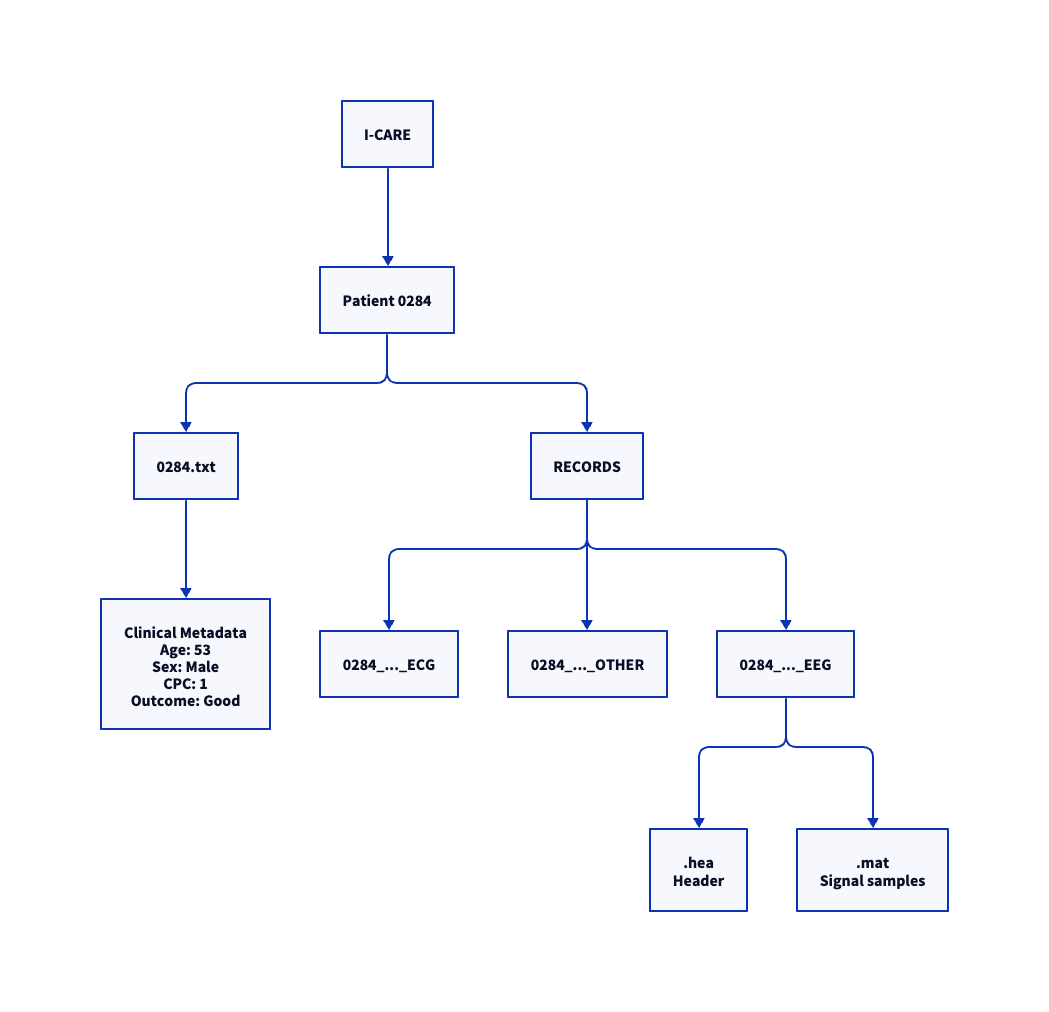

# Clinical

## **1. Limpieza de los Datos**
---

La elección de las técnicas de preprocesamiento puede diferir en cada conjunto de datos. Recuerde que es posible aplicar, según sea necesario (no necesariamente todas), las técnicas generales que se han explorado en el curso. La elección dependerá del tipo de datos con el que esté trabajando.

A lo largo de esta entrega, busque responder las siguientes preguntas:

- ¿Cuáles fueron los criterios utilizados para identificar y tratar valores atípicos, datos faltantes o cualquier otra anomalía en el conjunto de datos durante el proceso de limpieza?
- ¿Cómo se justificaría la necesidad de cada paso de preprocesamiento en términos de mejora de la calidad de los datos y preparación para el análisis subsiguiente?

A continuación encontrará los puntos a tratar a medida que va realizando la preparación de los datos. En cada punto defina el estado en que se encontraba el dataset, ademas de explicar y justificar las acciones y decisiones que se tomaron.

### **1.1. Valores faltantes**
---
Al encontrarnos con valores faltantes en el conjunto de datos, es crucial preguntarse:
* ¿Cómo afectan estos valores a la integridad y representatividad de la información?
* ¿Cómo se identificaron los valores faltantes en el conjunto de datos?
* ¿Cuáles fueron los criterios para decidir si rellenar con valores estimados o eliminar los valores faltantes? En caso que aplique, ¿qué método de relleno se utilizó y por qué se consideró apropiado?
* ¿Se realizó un análisis de la distribución de los valores faltantes en relación con las variables clave? Por ejemplo, si hay valores faltantes en una variable crítica, ¿cómo podría afectar la interpretación de los resultados?

In [49]:
import urllib3
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [50]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [51]:
BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"

# Sesión con reintentos automáticos para errores transitorios del servidor
# (502/503/504) y fallos de conexión, en vez de que todo el proceso se caiga
# por un solo paciente como pasó con el 0419.
session = requests.Session()
retries = Retry(
    total=5,
    backoff_factor=1.5,
    status_forcelist=[502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retries))

# 1. Índice de pacientes
response = session.get(RECORDS_URL, verify=False,timeout=30)
response.raise_for_status()
records = response.text.splitlines()
patient_ids = [record.strip("/").split("/")[-1] for record in records]
print("Número de pacientes encontrados:", len(patient_ids))

# 2. Descarga y parseo del archivo clínico de cada paciente
patients = []
failed_patients = []

for i, pid in enumerate(patient_ids, start=1):
    url = f"{BASE_URL}/training/{pid}/{pid}.txt"
    try:
        response = session.get(url, verify=False, timeout=30)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Fallo definitivo en paciente {pid}: {e}")
        failed_patients.append(pid)
        continue

    data = {}
    for line in response.text.strip().splitlines():
        key, value = line.split(":", 1)
        data[key.strip()] = value.strip()
    patients.append(data)

    if i % 100 == 0:
        print(f"Progreso: {i}/{len(patient_ids)} pacientes descargados")

print(f"\nDescarga completa: {len(patients)} ok, {len(failed_patients)} fallidos")
assert len(failed_patients) == 0, f"Revisar pacientes fallidos: {failed_patients}"

# 3. Consolidación en un único DataFrame integrado
clinical_df = pd.DataFrame(patients)
clinical_df.to_csv("icare_clinical_data.csv", index=False)

clinical_df.head()

Número de pacientes encontrados: 607
Progreso: 100/607 pacientes descargados
Progreso: 200/607 pacientes descargados
Progreso: 300/607 pacientes descargados
Progreso: 400/607 pacientes descargados
Progreso: 500/607 pacientes descargados
Progreso: 600/607 pacientes descargados

Descarga completa: 607 ok, 0 fallidos


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [52]:
clinical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Patient           607 non-null    str  
 1   Hospital          607 non-null    str  
 2   Age               607 non-null    str  
 3   Sex               607 non-null    str  
 4   ROSC              607 non-null    str  
 5   OHCA              607 non-null    str  
 6   Shockable Rhythm  607 non-null    str  
 7   TTM               607 non-null    str  
 8   Outcome           607 non-null    str  
 9   CPC               607 non-null    str  
dtypes: str(10)
memory usage: 47.6 KB


In [53]:
clinical_df.isnull().sum()

Patient             0
Hospital            0
Age                 0
Sex                 0
ROSC                0
OHCA                0
Shockable Rhythm    0
TTM                 0
Outcome             0
CPC                 0
dtype: int64

**Estado inicial del dataset antes de la conversión de tipos**

Al ejecutar `clinical_df.isnull().sum()` y `clinical_df.info()` justo después de la descarga, el resultado indica que las 10 columnas tienen 607 valores no nulos (0 valores faltantes en total) y que todas están almacenadas con tipo de dato `object` (texto).

Esto es engañoso y no significa que el dataset esté realmente completo ya que la forma en que se construyó `clinical_df` los datos provienen de archivos de texto plano de PhysioNet con formato `Variable: Value`, que se parsearon directamente a un diccionario y luego a un DataFrame, sin ninguna conversión de tipos todavía. En ese proceso, cualquier campo que en el archivo original no tenía valor quedó guardado como el texto literal `"nan"` (la palabra, como string), no como un valor nulo real de pandas.



Como `.isnull()` solo reconoce como faltante un `NaN` o `None` real, pero `"nan"` es una cadena de texto para Pandas, el conteo de nulos da 0 en todas las columnas.



**Ver todos los valores únicos de las variables numericas**

In [55]:
numeric_cols = ["Age", "ROSC", "TTM"]
for col in numeric_cols:
    valores_no_numericos = clinical_df.loc[
        pd.to_numeric(clinical_df[col], errors="coerce").isna(), col
    ].unique()
    print(f"{col}: valores no numéricos encontrados -> {valores_no_numericos}")

Age: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str
ROSC: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str
TTM: valores no numéricos encontrados -> <StringArray>
['nan']
Length: 1, dtype: str


Age: valores no numéricos encontrados -> ['nan'] significa que en la columna Age, el único valor que no se pudo convertir directamente a número es el texto "nan", es decir, algunos pacientes no tienen la edad registrada, y ese vacío quedó guardado como la palabra "nan" en vez de quedar realmente vacío. Lo mismo aplica para ROSC y TTM: en ambas, el único valor problemático es también "nan".

**Ver todos los valores únicos de las categóricas**

In [57]:
# Ver todos los valores únicos de las categóricas, para detectar cualquier código raro a simple vista
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]
for col in categorical_cols:
    print(f"{col}: {sorted(clinical_df[col].astype(str).unique())}")


Sex: ['Female', 'Male', 'nan']
Hospital: ['A', 'B', 'D', 'E', 'F']
OHCA: ['False', 'True', 'nan']
Shockable Rhythm: ['False', 'True', 'nan']
Outcome: ['Good', 'Poor']
CPC: ['1', '2', '3', '4', '5']


 Esto confirma que `Hospital`, `Outcome` y `CPC` no tienen valores faltantes, mientras que `Sex`, `OHCA` y `Shockable Rhythm` sí los tienen, codificados únicamente como el texto `"nan"`.

En conjunto, ambas verificaciones confirman que `"nan"` es el único código utilizado en todo el dataset para representar un valor faltante, no existen otros formatos ocultos que hayan podido pasar desapercibidos.

**Tratamiento de datos faltantes para las variables numericas**



Con la certeza de que `"nan"` es el único código de valor faltante presente en el dataset, se procede a convertir `Age`, `ROSC` y `TTM` a tipo numérico con `pd.to_numeric(..., errors="coerce")`.

Este método intenta convertir cada valor de la columna a número; cuando encuentra un valor que no puede convertir (en este caso, el texto `"nan"`), en vez de generar un error lo reemplaza automáticamente por un `NaN` real de pandas, reconocible por `.isnull()`.

El resultado (`clinical_df[numeric_cols].dtypes`) confirma que las tres columnas pasaron de `object` (texto) a `float64` (numérico decimal), quedando ya listas para calcular estadísticas, graficarlas y, en el conteo de nulos, reflejar por fin los valores faltantes reales que antes estaban ocultos como texto.

In [58]:
for col in numeric_cols:
    clinical_df[col] = pd.to_numeric(clinical_df[col], errors="coerce")

clinical_df[numeric_cols].dtypes

Age     float64
ROSC    float64
TTM     float64
dtype: object

Ahora revisemos como hacer el tratamiento de datos faltantes de los datos numericos

**Variable Age**

`Age` es una variable numérica continua que registra la edad del paciente en años. Presenta un único valor faltante sobre 607 registros, equivalente al 0.16% del conjunto, la menor proporción de todas las variables con datos incompletos.

En esta variable el tratamiento de faltantes involucra dos decisiones: si conservar o eliminar el registro afectado, y con qué estadístico realizar el relleno en caso de imputar. Cabe aclarar que `Age` presenta además una particularidad identificada en la Fase 2, la acumulación anómala de pacientes en el valor 90 producto de la censura por anonimización aplicada por los autores del conjunto de datos. 

In [60]:

n_total = len(clinical_df)
n_falt = clinical_df['Age'].isnull().sum()

print(f"Tipo de dato de Age: {clinical_df['Age'].dtype}")
print(f"Valores faltantes en Age: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Estadística descriptiva de Age (casos conocidos):")
print(clinical_df['Age'].describe().round(2).to_string())

print("\nPerfil del paciente sin dato de Age:")
print(clinical_df[clinical_df['Age'].isnull()][
    ['Patient', 'Hospital', 'Sex', 'OHCA', 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']
].to_string(index=False))

Tipo de dato de Age: float64
Valores faltantes en Age: 1 (0.16%)

Estadística descriptiva de Age (casos conocidos):
count    606.00
mean      61.17
std       15.65
min       16.00
25%       52.00
50%       63.00
75%       72.00
max       90.00

Perfil del paciente sin dato de Age:
Patient Hospital Sex OHCA Shockable Rhythm  ROSC Outcome CPC
   0592        F nan True            False   NaN    Good   1


La conversión de `Age` a tipo numérico confirma 1 valor faltante (0.16%) sobre 607 pacientes.

El examen del registro afectado arroja tres observaciones relevantes.

En primer lugar, se trata del paciente 0592, cuya fila presenta también valores faltantes en `Sex` y en `ROSC`. Es el único paciente con un registro demográfico incompleto, lo que sugiere un problema puntual de captura del caso y no una deficiencia propia de la variable `Age`.

El paciente cuenta con la variable objetivo completa: registra `Outcome = Good` y `CPC = 1`, es decir, recuperación neurológica completa, junto con `Shockable Rhythm = False`. Esta combinación es poco frecuente en el conjunto, dado que únicamente el 17.3% de los pacientes sin ritmo desfibrilable alcanzan un desenlace favorable. Eliminar el registro implicaría perder uno de los 225 casos de la clase minoritaria `Good` y, adicionalmente, uno de los pocos casos que documentan esa combinación clínica particular, argumento que refuerza la decisión de imputar en lugar de descartar el registro.

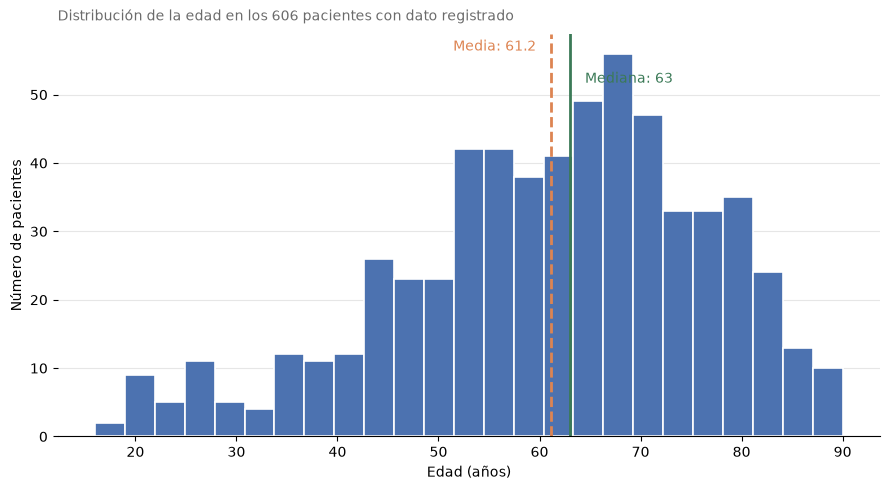

Asimetría (skew): -0.592
Media: 61.17  |  Mediana: 63.0  |  Diferencia: 1.83 años


In [61]:
edad = clinical_df['Age'].dropna()
media = edad.mean()
mediana = edad.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(edad, bins=25, color='#4C72B0', edgecolor='white', linewidth=1.2)

ax.axvline(media, color='#DD8452', linestyle='--', linewidth=2)
ax.axvline(mediana, color='#3B7A57', linestyle='-', linewidth=2)

ymax = ax.get_ylim()[1]
ax.text(media - 1.5, ymax * 0.96, f'Media: {media:.1f}', color='#DD8452',
        ha='right', fontsize=10)
ax.text(mediana + 1.5, ymax * 0.88, f'Mediana: {mediana:.0f}', color='#3B7A57',
        ha='left', fontsize=10)


ax.text(0, 1.035,
        f'Distribución de la edad en los {len(edad)} pacientes con dato registrado',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de pacientes')
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Asimetría (skew): {edad.skew():.3f}")
print(f"Media: {media:.2f}  |  Mediana: {mediana:.1f}  |  Diferencia: {abs(media-mediana):.2f} años")

El histograma confirma que la distribución de `Age` no es simétrica. El coeficiente de asimetría es de -0.592, un valor negativo que indica un sesgo hacia la izquierda de magnitud moderada, es decir, una cola que se extiende hacia las edades menores mientras el grueso de los datos se concentra en el extremo superior.

Visualmente esto se traduce en que la mayor densidad de pacientes se ubica entre los 50 y los 85 años, con el pico en el rango de 65 a 70, mientras que por debajo de los 45 años los casos son escasos y dispersos, extendiéndose hasta un mínimo de 16 años. Debido a lo anterior, la cola de pacientes jóvenes es la que arrastra la media hacia abajo.

La consecuencia directa se observa al comparar las dos medidas de tendencia central: la media es de 61.17 años y la mediana de 63.0, una diferencia de 1.83 años en la que la media queda por debajo de la mediana. En una distribución perfectamente simétrica ambos valores coincidirían, y su separación es precisamente la manifestación numérica del sesgo.

Por este motivo se seleccionó la **mediana** como estadístico de imputación. En distribuciones asimétricas la mediana constituye el estimador robusto de tendencia central, ya que depende de la posición central de los datos y no de la magnitud de los valores extremos, mientras que la media se desplaza en dirección a la cola y resulta menos representativa del paciente típico de la cohorte.

Cabe señalar adicionalmente que parte de esta asimetría es de origen artificial: la censura por anonimización aplicada por los autores del conjunto agrupa en el valor 90 a todos los pacientes mayores de 89 años, lo que trunca la cola derecha de la distribución y acentúa el sesgo negativo observado. Esta particularidad se aborda en detalle en la sección de valores atípicos.

In [63]:
escenarios = {
    'Sin tratar (n=606)': clinical_df['Age'].dropna(),
    'Eliminando el registro (n=606)': clinical_df['Age'].dropna(),
    'Imputando con la mediana (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].median()),
    'Imputando con la media (n=607)': clinical_df['Age'].fillna(clinical_df['Age'].mean()),
}

resumen = pd.DataFrame({
    nombre: {
        'n': int(serie.count()),
        'Media': round(serie.mean(), 2),
        'Mediana': round(serie.median(), 2),
        'Desv. estándar': round(serie.std(), 2),
    }
    for nombre, serie in escenarios.items()
}).T

print("Efecto de cada alternativa de tratamiento sobre la distribución de Age:\n")
print(resumen.to_string())

Efecto de cada alternativa de tratamiento sobre la distribución de Age:

                                      n  Media  Mediana  Desv. estándar
Sin tratar (n=606)                606.0  61.17     63.0           15.65
Eliminando el registro (n=606)    606.0  61.17     63.0           15.65
Imputando con la mediana (n=607)  607.0  61.17     63.0           15.64
Imputando con la media (n=607)    607.0  61.17     63.0           15.64


Respecto al análisis del faltante frente a variables clave, el paciente afectado cuenta con información completa en el resto de las variables del conjunto, incluida la variable objetivo `Outcome`. Y la decisión de tratamiento se fundamenta en el efecto que cada alternativa produce sobre la distribución de la variable.

**Criterio de decisión y tratamiento aplicado para `Age`**

Se aplicó **imputación con la mediana (63 años)**, decisión que responde a dos criterios independientes.

El primero es si conservar o eliminar el registro. El análisis de sensibilidad muestra que la media, la mediana y la desviación estándar de `Age` permanecen prácticamente idénticas bajo cualquiera de las alternativas, por lo que la decisión resulta indiferente en términos de la distribución de la variable. Siendo así, el criterio pasa a ser preservar la mayor cantidad de información posible: eliminar el registro implicaría descartar también los datos completos de ese paciente en `Shockable Rhythm`, `OHCA`, `ROSC` y `Outcome`, sacrificando información valiosa a cambio de ningún beneficio.

El segundo criterio es con qué estadístico rellenar. Se optó por la mediana en lugar de la media porque la distribución de `Age` no es simétrica: presenta un sesgo hacia las edades menores, con valores atípicos de pacientes jóvenes por debajo de los 20 años y una acumulación artificial en el extremo superior producto de la censura en 90 años. En distribuciones asimétricas y con valores extremos, la mediana es el estimador robusto de tendencia central, mientras que la media se desplaza en dirección a los valores extremos y resulta menos representativa del paciente típico del conjunto.

In [65]:
mediana_age = clinical_df['Age'].median()
clinical_df['Age'] = clinical_df['Age'].fillna(mediana_age)

print(f"Imputación aplicada con la mediana: {mediana_age:.0f} años\n")
print("Estadística descriptiva final de Age:")
print(clinical_df['Age'].describe().round(2).to_string())

print(f"\nValores faltantes restantes en Age: {clinical_df['Age'].isnull().sum()}")
assert clinical_df['Age'].isnull().sum() == 0, "Aún quedan faltantes en Age"
print("Verificación superada: la variable Age no contiene valores faltantes.")

Imputación aplicada con la mediana: 63 años

Estadística descriptiva final de Age:
count    607.00
mean      61.17
std       15.64
min       16.00
25%       52.00
50%       63.00
75%       72.00
max       90.00

Valores faltantes restantes en Age: 0
Verificación superada: la variable Age no contiene valores faltantes.


**Variable `ROSC`**



`ROSC` (Return of Spontaneous Circulation) es una variable numérica continua que registra el tiempo transcurrido, en minutos, hasta el retorno de la circulación espontánea del paciente. Presenta 304 valores faltantes sobre 607 registros, equivalentes al 50.1% del conjunto, la proporción más alta de todo el dataset.

Este caso requiere un tratamiento distinto al de `Age`. Cuando la mitad de los valores de una variable están ausentes, la decisión no se limita a elegir un estadístico de relleno, sino que debe evaluarse previamente si la imputación es siquiera un procedimiento apropiado, dado que rellenar 304 registros implicaría que la mitad del contenido de la variable sería información generada artificialmente y no observada.

El análisis se estructura en cuatro pasos:
* Determinar el origen del faltante.
* Evaluar si su ausencia lleva información propia respecto al desenlace.
* Verificar si dicha asociación es genuina o está confundida por otra variable.
* Cuantificar el efecto que tendría la imputación sobre la distribución.




1. ¿Los pacientes sin dato presentan un desenlace distinto al de los demás?
2. Si es así, ¿esa diferencia se debe realmente a la ausencia del dato o a algún otro factor?
3. ¿Qué ocurre al controlar ese factor?
4. ¿Es viable imputar los valores faltantes?

In [66]:
clinical_df['ROSC'] = pd.to_numeric(clinical_df['ROSC'], errors='coerce')

n_total = len(clinical_df)
n_falt = clinical_df['ROSC'].isnull().sum()

print(f"Pacientes totales: {n_total}")
print(f"Pacientes sin dato de ROSC: {n_falt} ({n_falt/n_total*100:.1f}%)")
print(f"Pacientes con dato de ROSC: {n_total - n_falt}\n")

print("Estadística descriptiva de los casos con dato:")
print(clinical_df['ROSC'].describe().round(2).to_string())
print(f"\nAsimetría: {clinical_df['ROSC'].skew():.2f}   Curtosis: {clinical_df['ROSC'].kurt():.2f}")

Pacientes totales: 607
Pacientes sin dato de ROSC: 304 (50.1%)
Pacientes con dato de ROSC: 303

Estadística descriptiva de los casos con dato:
count    303.00
mean      23.27
std       18.79
min        1.00
25%       10.00
50%       19.00
75%       30.00
max      111.00

Asimetría: 1.85   Curtosis: 4.21




Solo 303 de los 607 pacientes cuentan con el dato. Entre ellos, el tiempo hasta la recuperación de la circulación tiene una mediana de 19 minutos y una media de 23.27, con valores que van de 1 a 111 minutos.

La asimetría de 1.85 y la curtosis de 4.21 indican una distribución con la mayoría de los casos en tiempos cortos y una cola larga de reanimaciones prolongadas. Por eso la media supera a la mediana en más de cuatro minutos: los casos extremos la arrastran hacia arriba.

Primera pregunta: ¿los pacientes sin dato presentan un desenlace distinto?

Antes de decidir cómo tratar los registros ausentes se debe verificar si corresponden a pacientes comparables al resto o si constituyen un grupo con características propias. La forma de comprobarlo es comparar el desenlace neurológico de ambos grupos.

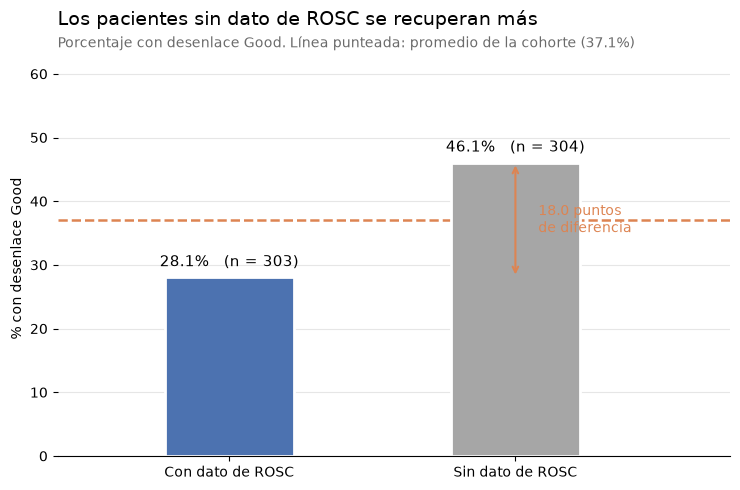

In [67]:
grupo = clinical_df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
tabla = pd.crosstab(grupo, clinical_df['Outcome']).reindex(['Con dato', 'Sin dato'])
pct_good = tabla['Good'] / tabla.sum(axis=1) * 100
conteos = tabla.sum(axis=1)
baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
barras = ax.bar(['Con dato de ROSC', 'Sin dato de ROSC'], pct_good.values, width=0.45,
                color=['#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%   (n = {int(n)})', ha='center', va='bottom', fontsize=10.5)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)
ax.annotate('', xy=(1, pct_good['Sin dato']), xytext=(1, pct_good['Con dato']),
            arrowprops=dict(arrowstyle='<->', color='#DD8452', lw=1.5))
ax.text(1.08, (pct_good['Sin dato'] + pct_good['Con dato'])/2,
        f"{pct_good['Sin dato'] - pct_good['Con dato']:.1f} puntos\nde diferencia",
        fontsize=10, color='#DD8452', va='center')

ax.set_title('Los pacientes sin dato de ROSC se recuperan más',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje con desenlace Good. Línea punteada: promedio de la cohorte ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, 62)
ax.set_xlim(-0.6, 1.75)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

Respuesta: sí, pero el resultado no tiene sentido clínico

Los pacientes sin dato de `ROSC` presentan un 46.1% de desenlaces favorables, frente a un 28.1% entre quienes sí lo tienen. Una diferencia de 18 puntos porcentuales.

Interpretado de forma literal, este resultado afirmaría que no tener el dato registrado mejora el pronóstico del paciente, lo cual es imposible: la omisión de un campo en un formulario no puede influir en la recuperación neurológica de nadie.

Cuando una comparación arroja un resultado sin sentido, la explicación habitual es que los dos grupos comparados difieren en algo más además de la característica que se está evaluando.

Segunda pregunta: ¿de dónde provienen los registros sin dato?

Si los pacientes sin dato no están repartidos de forma homogénea entre los hospitales, entonces la comparación anterior podría estar midiendo diferencias entre instituciones en lugar del efecto del dato ausente.

Disponibilidad de ROSC y desenlace por hospital:
              n  % sin dato ROSC  % Good
Hospital                                
A         261.0            100.0    46.7
B         120.0              0.0    28.3
D          83.0             26.5    32.5
E          74.0              2.7    20.3
F          69.0             27.5    39.1


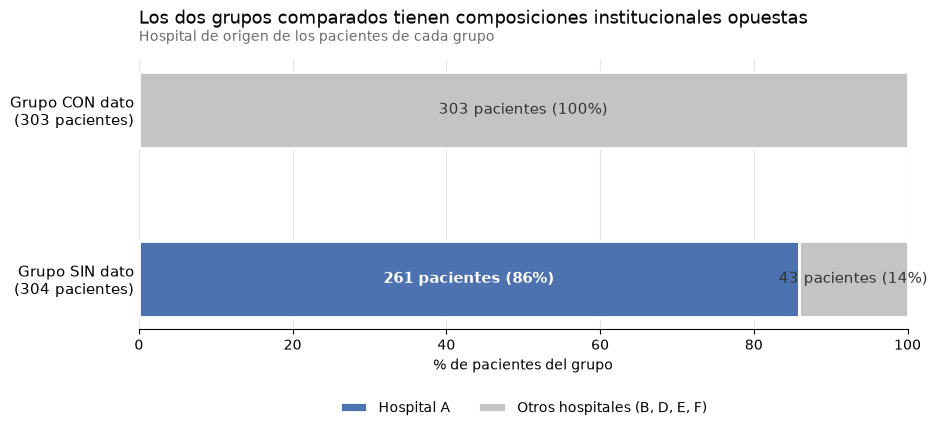

In [68]:
print("Disponibilidad de ROSC y desenlace por hospital:")
resumen_hosp = clinical_df.groupby('Hospital').apply(
    lambda g: pd.Series({
        'n': len(g),
        '% sin dato ROSC': g['ROSC'].isnull().mean() * 100,
        '% Good': (g['Outcome'] == 'Good').mean() * 100,
    }), include_groups=False
).round(1)
print(resumen_hosp.to_string())

# Composición de cada grupo según su hospital de origen
es_A = clinical_df['Hospital'] == 'A'
n_con = (grupo == 'Con dato').sum()
n_sin = (grupo == 'Sin dato').sum()
a_con = ((grupo == 'Con dato') & es_A).sum()
a_sin = ((grupo == 'Sin dato') & es_A).sum()

pct_a = [a_con/n_con*100, a_sin/n_sin*100]
pct_otros = [(n_con-a_con)/n_con*100, (n_sin-a_sin)/n_sin*100]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = [0, 1]
ax.barh(y, pct_a, 0.45, label='Hospital A', color='#4C72B0', edgecolor='white', linewidth=2)
ax.barh(y, pct_otros, 0.45, left=pct_a, label='Otros hospitales (B, D, E, F)',
        color='#C4C4C4', edgecolor='white', linewidth=2)

datos = [(pct_a[0], pct_otros[0], a_con, n_con-a_con, 0),
         (pct_a[1], pct_otros[1], a_sin, n_sin-a_sin, 1)]
for pa, po, na, no, i in datos:
    if pa > 5:
        ax.text(pa/2, i, f'{na} pacientes ({pa:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='white', weight='bold')
    if po > 5:
        ax.text(pa + po/2, i, f'{no} pacientes ({po:.0f}%)', ha='center', va='center',
                fontsize=10.5, color='#333333')

ax.set_yticks(y)
ax.set_yticklabels([f'Grupo CON dato\n({n_con} pacientes)', f'Grupo SIN dato\n({n_sin} pacientes)'],
                   fontsize=10.5)
ax.set_xlim(0, 100)
ax.set_xlabel('% de pacientes del grupo')
ax.invert_yaxis()
ax.set_title('Los dos grupos comparados tienen composiciones institucionales opuestas',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.07, 'Hospital de origen de los pacientes de cada grupo',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.xaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: los faltantes provienen casi en su totalidad de un solo hospital

| Hospital | n | % sin dato de ROSC | % desenlace Good |
|---|---|---|---|
| A | 261 | 100.0% | 46.7% |
| B | 120 | 0.0% | 28.3% |
| D | 83 | 26.5% | 32.5% |
| E | 74 | 2.7% | 20.3% |
| F | 69 | 27.5% | 39.1% |

El Hospital A no registra esta variable en ninguno de sus 261 pacientes, mientras que el Hospital B la registra en los 120 suyos. No se trata de omisiones aisladas sino de una diferencia de protocolo entre instituciones.

La consecuencia se aprecia en el gráfico de composición: el grupo con dato no contiene ni un solo paciente del Hospital A, mientras que el grupo sin dato está formado en un 86% por pacientes de esa institución. Los dos grupos que se compararon en la primera pregunta no eran por lo tanto comparables entre sí.

Y aquí aparece el elemento decisivo: el Hospital A es además el que presenta el mejor desenlace de todo el conjunto, con 46.7% de recuperaciones favorables frente a un rango de 20.3% a 39.1% en los demás centros.

Esto significa que la comparación inicial no medía el efecto de la ausencia del dato, sino en gran medida el de pertenecer al Hospital A. La condición "no tener dato de ROSC" estaba funcionando como un sustituto de la condición "ser paciente del Hospital A".

¿Tercera pregunta: ¿qué ocurre si se elimina ese factor?

Si la diferencia la produjera realmente el dato ausente, excluir un hospital del análisis no debería alterarla de forma apreciable. Si en cambio la producía el Hospital A, la diferencia debería reducirse al retirarlo.

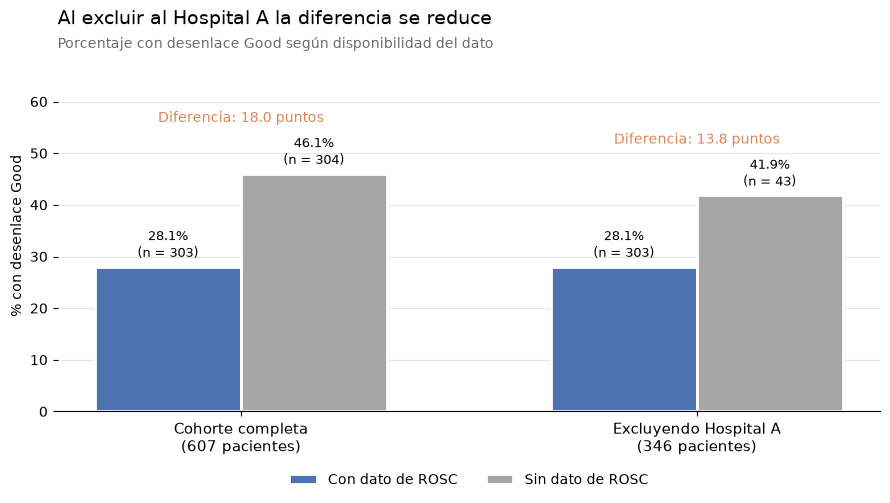

In [69]:
def desenlace_por_disponibilidad(df):
    g = df['ROSC'].isnull().map({False: 'Con dato', True: 'Sin dato'})
    t = pd.crosstab(g, df['Outcome']).reindex(['Con dato', 'Sin dato'])
    return (t['Good'] / t.sum(axis=1) * 100), t.sum(axis=1)

pct_full, n_full = desenlace_por_disponibilidad(clinical_df)
sin_A = clinical_df[clinical_df['Hospital'] != 'A']
pct_sinA, n_sinA = desenlace_por_disponibilidad(sin_A)

x = np.arange(2)
w = 0.32
con = [pct_full['Con dato'], pct_sinA['Con dato']]
sin = [pct_full['Sin dato'], pct_sinA['Sin dato']]
n_con_l = [n_full['Con dato'], n_sinA['Con dato']]
n_sin_l = [n_full['Sin dato'], n_sinA['Sin dato']]

fig, ax = plt.subplots(figsize=(9, 5.2))
b1 = ax.bar(x - w/2, con, w, label='Con dato de ROSC', color='#4C72B0',
            edgecolor='white', linewidth=2)
b2 = ax.bar(x + w/2, sin, w, label='Sin dato de ROSC', color='#A6A6A6',
            edgecolor='white', linewidth=2)

for barras, enes in ((b1, n_con_l), (b2, n_sin_l)):
    for barra, n in zip(barras, enes):
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.0,
                f'{alto:.1f}%\n(n = {int(n)})', ha='center', va='bottom', fontsize=9.5)

for i, (c, s) in enumerate(zip(con, sin)):
    ax.text(i, max(c, s) + 10, f'Diferencia: {s-c:.1f} puntos',
            ha='center', fontsize=10, color='#DD8452')

ax.set_title('Al excluir al Hospital A la diferencia se reduce',
             fontsize=13.5, pad=26, loc='left')
ax.text(0, 1.035, 'Porcentaje con desenlace Good según disponibilidad del dato',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_xticks(x)
ax.set_xticklabels(['Cohorte completa\n(607 pacientes)',
                    f'Excluyendo Hospital A\n({len(sin_A)} pacientes)'], fontsize=10.5)
ax.set_ylim(0, 68)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)

plt.tight_layout()
plt.show()

Respuesta: parte de la diferencia se explica por el hospital, y el resto no puede evaluarse

Al excluir al Hospital A, la diferencia baja de 18 a 13.8 puntos porcentuales, quedando repartida en dos porciones.

Los 4.2 puntos que desaparecen corresponden al Hospital A. La atribución es inequívoca porque el grupo con dato no cambió entre ambos escenarios, ya que ninguno de esos 303 pacientes pertenecía a esa institución. Queda confirmado que parte del efecto aparente venía del hospital y no del dato ausente.

Los 13.8 puntos restantes no pueden evaluarse, porque ahora se calculan sobre 43 pacientes en lugar de 304. Con ese tamaño, cada paciente vale 2.3 puntos del resultado, de modo que el cambio de desenlace de tres casos bastaría para reducir la diferencia a la mitad. No se afirma que sea inexistente, sino que la muestra es demasiado pequeña para saberlo.

Cuarta pregunta: ¿es viable imputar los valores faltantes?

Descartado que el faltante tenga significado propio, queda por resolver si conviene rellenarlo. Para decidirlo se compara la distribución real de la variable con la que resultaría después de imputar.

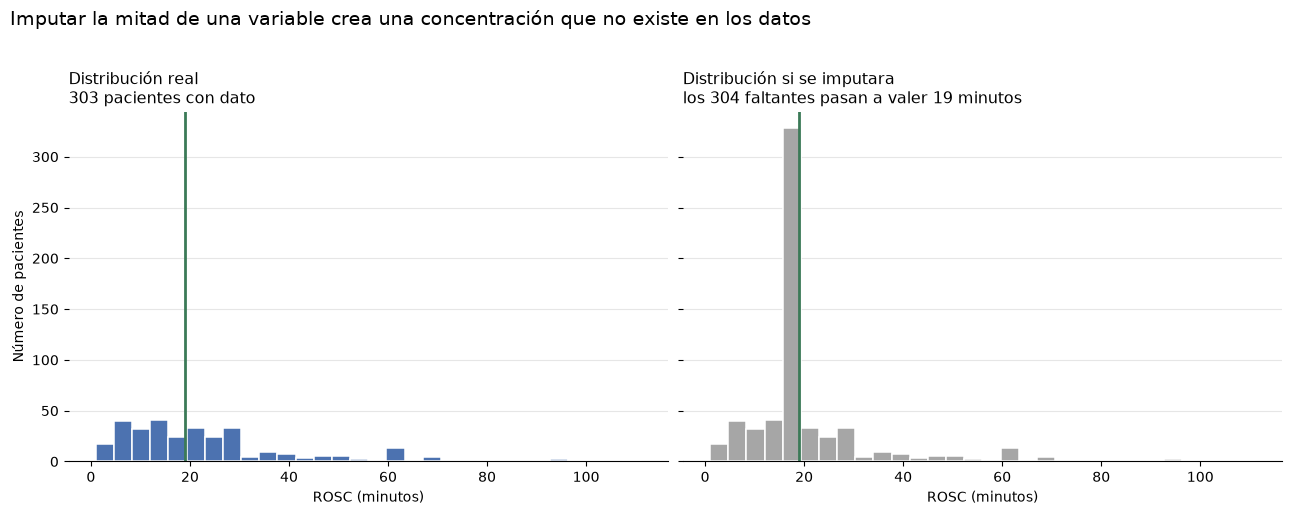

Desviación estándar real: 18.79
Desviación estándar tras imputar: 13.44
Pérdida de variabilidad: 28.5%


In [70]:
rosc = clinical_df['ROSC'].dropna()
mediana_rosc = rosc.median()
imputado = clinical_df['ROSC'].fillna(mediana_rosc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax1.hist(rosc, bins=30, color='#4C72B0', edgecolor='white', linewidth=1.1)
ax1.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax1.set_title(f'Distribución real\n{len(rosc)} pacientes con dato', fontsize=11.5, loc='left')
ax1.set_xlabel('ROSC (minutos)')
ax1.set_ylabel('Número de pacientes')

ax2.hist(imputado, bins=30, color='#A6A6A6', edgecolor='white', linewidth=1.1)
ax2.axvline(mediana_rosc, color='#3B7A57', linewidth=2)
ax2.set_title(f'Distribución si se imputara\nlos 304 faltantes pasan a valer {mediana_rosc:.0f} minutos',
              fontsize=11.5, loc='left')
ax2.set_xlabel('ROSC (minutos)')

for ax in (ax1, ax2):
    ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ('top', 'right', 'left'):
        ax.spines[lado].set_visible(False)

fig.suptitle('Imputar la mitad de una variable crea una concentración que no existe en los datos',
             fontsize=13.5, x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.show()

print(f"Desviación estándar real: {rosc.std():.2f}")
print(f"Desviación estándar tras imputar: {imputado.std():.2f}")
print(f"Pérdida de variabilidad: {(1 - imputado.std()/rosc.std())*100:.1f}%")

Respuesta: no es viable imputar

El contraste entre ambos histogramas muestra el efecto de rellenar los 304 registros con la mediana: se genera una acumulación de más de 320 pacientes en el valor de 19 minutos, una concentración inexistente en los datos observados. La desviación estándar cae de 18.79 a 13.44, lo que representa una pérdida del 28.5% de la variabilidad de la variable.

En una variable donde los valores ausentes constituyen la mitad del conjunto, la imputación implica que la mitad de su contenido pasaría a ser información generada artificialmente.

**Criterio de decisión y tratamiento aplicado**

Ninguna de las tres alternativas convencionales resulta apropiada. Imputar distorsionaría la distribución en la magnitud descrita. Eliminar los registros implicaría descartar 304 pacientes, más de la mitad de la cohorte y la totalidad del Hospital A. Y conservar una variable indicadora del faltante carece de justificación, dado que se demostró que la ausencia del dato no aporta información clínica sino institucional.

El tratamiento adoptado consta por lo tanto de dos componentes.

El primero es conservar la variable numérica `ROSC` con sus valores nulos, sin modificación. En pandas, `NaN` constituye la representación nativa del dato no disponible en variables numéricas y se excluye de forma automática del cálculo de estadísticos y de la generación de gráficos. Los análisis sobre el tiempo exacto de reanimación se realizan en consecuencia sobre los 303 pacientes con información disponible.

El segundo responde a una limitación del primero: mantener los valores nulos deja al 50.1% de la cohorte inutilizable en cualquier análisis que requiera la variable. Por ello se construye adicionalmente `ROSC_cat`, una versión agrupada en tres rangos definidos por los cuartiles observados, que incorpora la ausencia del dato como una categoría explícita.



In [72]:
# 1. La variable numérica conserva sus valores nulos, sin imputar.
print(f"Valores nulos conservados en ROSC: {clinical_df['ROSC'].isnull().sum()} "
      f"({clinical_df['ROSC'].isnull().mean()*100:.1f}%)")
print(f"Pacientes con dato disponible: {clinical_df['ROSC'].notna().sum()}")

# 2. Versión agrupada que mantiene utilizable a toda la cohorte.
#    Cortes definidos por los cuartiles observados (Q1 = 10, Q3 = 30).
clinical_df['ROSC_cat'] = pd.cut(
    clinical_df['ROSC'],
    bins=[0, 10, 30, float('inf')],
    labels=['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)']
)
clinical_df['ROSC_cat'] = clinical_df['ROSC_cat'].cat.add_categories('Sin dato').fillna('Sin dato')

orden_cat = ['Rápido (1-10 min)', 'Intermedio (11-30 min)', 'Prolongado (>30 min)', 'Sin dato']

print("\nDistribución de ROSC_cat:")
for cat, n in clinical_df['ROSC_cat'].value_counts().reindex(orden_cat).items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

# 3. Validación: los rangos deben conservar la relación con el desenlace
print("\n% con desenlace Good por categoría:")
val = clinical_df.groupby('ROSC_cat', observed=True).apply(
    lambda g: (g['Outcome'] == 'Good').mean() * 100, include_groups=False
).reindex(orden_cat).round(1)
print(val.to_string())

assert clinical_df['ROSC_cat'].isnull().sum() == 0, "ROSC_cat contiene nulos"
print(f"\nVerificación superada: ROSC_cat cubre los {len(clinical_df)} pacientes sin valores nulos.")

Valores nulos conservados en ROSC: 304 (50.1%)
Pacientes con dato disponible: 303

Distribución de ROSC_cat:
  Rápido (1-10 min): 86 (14.2%)
  Intermedio (11-30 min): 158 (26.0%)
  Prolongado (>30 min): 59 (9.7%)
  Sin dato: 304 (50.1%)

% con desenlace Good por categoría:
ROSC_cat
Rápido (1-10 min)         38.4
Intermedio (11-30 min)    26.6
Prolongado (>30 min)      16.9
Sin dato                  46.1

Verificación superada: ROSC_cat cubre los 607 pacientes sin valores nulos.



Debe dejarse explícito que, al no registrar el Hospital A esta variable en ninguno de sus pacientes, todo análisis sobre `ROSC` en este proyecto, incluidos los realizados en la Fase 2, se sustenta en una subcohorte que excluye por completo a la institución que aporta el 43% de los pacientes y que además presenta el mejor desenlace del conjunto. Los hallazgos sobre la relación entre el tiempo hasta el retorno de la circulación espontánea y el desenlace neurológico deben interpretarse por lo tanto como válidos para los hospitales B, D, E y F, sin que pueda asumirse su generalización a la totalidad de la cohorte.

Esta limitación afecta específicamente a los análisis que emplean la variable numérica `ROSC`, calculados sobre los 303 pacientes con dato disponible. Los análisis que utilicen `ROSC_cat` sí abarcan la totalidad de los 607 registros, aunque en ellos el Hospital A queda representado íntegramente dentro de la categoría "Sin dato", de modo que cualquier comparación entre esa categoría y las demás estará reflejando también una diferencia institucional y no únicamente el tiempo de reanimación.

Finalmente, esta situación constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos, dado que evidencia una ausencia de estandarización en los protocolos de registro entre las instituciones del consorcio, y debería tenerse en cuenta en cualquier estudio posterior que pretenda emplear esta variable como predictor del desenlace neurológico.

**Variable TTM**

`TTM` (Targeted Temperature Management) registra la temperatura objetivo del manejo de temperatura dirigido aplicado al paciente, expresada en grados centígrados. Presenta 98 valores faltantes sobre 607 registros, equivalentes al 16.1% del conjunto.

Esta variable constituye el único caso del conjunto de datos en el que la ausencia del valor no representa un problema de calidad, sino información clínica en sí misma. Según la documentación oficial de I-CARE, el valor nulo en `TTM` no corresponde a un dato que no se logró capturar, sino que está codificado de forma explícita para indicar que al paciente no se le aplicó manejo de temperatura dirigido. Se trata por lo tanto de un faltante estructural: el dato no existe porque el procedimiento no se realizó, no porque se haya omitido su registro.

Esta distinción cambia por completo el criterio de tratamiento. En las variables anteriores la pregunta era cómo manejar la ausencia de una información que sí existía; aquí la pregunta es cómo representar una categoría clínica que el formato numérico de la variable no permite expresar.

In [73]:


n_total = len(clinical_df)
n_falt = clinical_df['TTM'].isnull().sum()

print(f"Tipo de dato: {clinical_df['TTM'].dtype}")
print(f"Valores faltantes en TTM: {n_falt} ({n_falt/n_total*100:.1f}%)\n")

print("Valores observados en la variable:")
print(clinical_df['TTM'].value_counts(dropna=False).sort_index().to_string())

print("\nEstadística descriptiva de los casos con dato:")
print(clinical_df['TTM'].describe().round(2).to_string())

print("\nDistribución por hospital de los pacientes SIN TTM:")
falt_hosp = clinical_df.loc[clinical_df['TTM'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Sin TTM': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Sin TTM'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Tipo de dato: float64
Valores faltantes en TTM: 98 (16.1%)

Valores observados en la variable:
TTM
33.0    448
36.0     61
NaN      98

Estadística descriptiva de los casos con dato:
count    509.00
mean      33.36
std        0.98
min       33.00
25%       33.00
50%       33.00
75%       33.00
max       36.00

Distribución por hospital de los pacientes SIN TTM:
          Sin TTM  Total pacientes  % del hospital
Hospital                                          
A               2              261             0.8
B               9              120             7.5
D              20               83            24.1
E               3               74             4.1
F              64               69            92.8




La variable presenta únicamente dos valores distintos en los 509 pacientes con dato: 33 °C en 448 casos y 36 °C en 61. Esto confirma de forma definitiva que `TTM` no constituye una variable continua sino una categórica almacenada en formato numérico, correspondiente a dos protocolos clínicos de temperatura objetivo. La media de 33.36 que arroja la estadística descriptiva carece de sentido clínico, dado que ningún paciente registra esa temperatura.

Respecto al origen de los 98 casos sin TTM, la distribución institucional es la siguiente:

| Hospital | Sin TTM | Total pacientes | % del hospital |
|---|---|---|---|
| A | 2 | 261 | 0.8% |
| B | 9 | 120 | 7.5% |
| D | 20 | 83 | 24.1% |
| E | 3 | 74 | 4.1% |
| F | 64 | 69 | 92.8% |

El Hospital F concentra 64 de los 98 casos, es decir el 65% del total, y no aplica el procedimiento en el 92.8% de sus pacientes. A diferencia de lo observado en `ROSC`, donde la ausencia del dato respondía a una omisión de registro, aquí el patrón refleja una decisión de protocolo clínico: esa institución no incorpora el manejo de temperatura dirigido en su práctica habitual. 

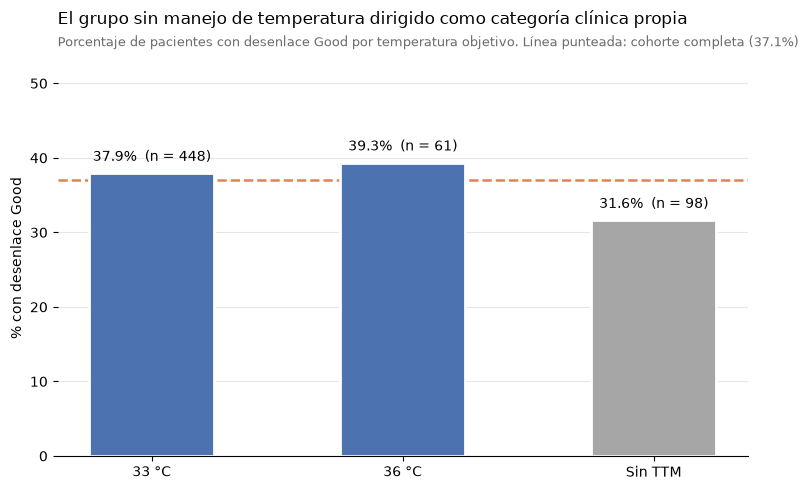

TTM_grupo
33 °C      37.9
36 °C      39.3
Sin TTM    31.6


In [74]:
clinical_df['TTM_grupo'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']
tabla = pd.crosstab(clinical_df['TTM_grupo'], clinical_df['Outcome']).reindex(orden)
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(orden, pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'],
                edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {int(n)})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)

ax.set_title('El grupo sin manejo de temperatura dirigido como categoría clínica propia',
             fontsize=12.5, pad=26, loc='left')
ax.text(0, 1.035,
        f'Porcentaje de pacientes con desenlace Good por temperatura objetivo. '
        f'Línea punteada: cohorte completa ({baseline:.1f}%)',
        transform=ax.transAxes, fontsize=9.5, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

Comportamiento del grupo sin TTM frente al desenlace

| Categoría | % con desenlace Good | n |
|---|---|---|
| 33 °C | 37.9% | 448 |
| 36 °C | 39.3% | 61 |
| Sin TTM | 31.6% | 98 |
| **Cohorte completa** | **37.1%** | **607** |

Dos observaciones se desprenden de esta comparación.

La primera es que ambas temperaturas objetivo producen resultados prácticamente equivalentes, con una diferencia de apenas 1.4 puntos porcentuales entre 33 y 36 grados. Este hallazgo es consistente con la evidencia clínica disponible, que no ha logrado establecer una ventaja de la hipotermia profunda frente al control de temperatura menos agresivo.



**Criterio de decisión y tratamiento aplicado en el  `TTM`**

Se decidió recodificar `TTM` como variable categórica de tres niveles**: `33 °C`, `36 °C` y `Sin TTM`.

La decisión se fundamenta en que ninguna de las alternativas habituales resulta admisible en este caso. Imputar un valor sería el error más grave, porque asignar 33 o 36 grados a esos 98 pacientes equivaldría a afirmar que recibieron un tratamiento que en realidad nunca se les administró. No se trataría de una aproximación estadística imprecisa sino de una afirmación clínicamente falsa. Eliminar los registros tampoco procede, dado que no existe ningún dato perdido que justifique descartarlos: la información sobre esos pacientes está completa, y lo que el valor nulo indica es precisamente que el procedimiento no se aplicó. Y conservar el valor como `NaN`, que fue la solución adoptada para `ROSC`, resultaría aquí inadecuado, porque `NaN` significa "dato desconocido" mientras que en esta variable el contenido real es "condición clínica conocida y documentada".

La recodificación como categoría explícita es por lo tanto la única representación fiel al significado del dato. El análisis previo la respalda empíricamente, al mostrar que el grupo sin TTM presenta un comportamiento diferenciado frente al desenlace que no se explica por el hospital de procedencia.

La conversión a tipo categórico no implica además ninguna pérdida de información, dado que la variable solo contiene dos valores distintos y su formato numérico original nunca aportó capacidad analítica real. Por el contrario, la recodificación corrige una inconsistencia entre el tipo de dato y la naturaleza de la variable que venía arrastrándose desde la adquisición, y permite que los 607 pacientes queden disponibles para cualquier análisis posterior, frente a los 509 que resultaban utilizables en su formato original.

In [75]:
# Recodificación de TTM como variable categórica de tres niveles.
# El valor nulo no representa un dato desconocido sino una condición clínica
# documentada: el paciente no recibió manejo de temperatura dirigido.
clinical_df['TTM_cat'] = clinical_df['TTM'].apply(
    lambda x: 'Sin TTM' if pd.isna(x) else f'{x:.0f} °C'
)

orden = ['33 °C', '36 °C', 'Sin TTM']

print("Distribución final de TTM_cat:")
dist = clinical_df['TTM_cat'].value_counts().reindex(orden)
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nPacientes utilizables: {clinical_df['TTM_cat'].notna().sum()} de {len(clinical_df)}")
print(f"Valores nulos en TTM_cat: {clinical_df['TTM_cat'].isnull().sum()}")

assert clinical_df['TTM_cat'].isnull().sum() == 0, "TTM_cat contiene nulos"
print("\nVerificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.")

Distribución final de TTM_cat:
  33 °C: 448 (73.8%)
  36 °C: 61 (10.0%)
  Sin TTM: 98 (16.1%)

Pacientes utilizables: 607 de 607
Valores nulos en TTM_cat: 0

Verificación superada: TTM_cat cubre la totalidad de la cohorte sin valores nulos.


**Tratamiento de datos faltantes para las variables categoricas**

In [76]:
categorical_cols = ["Sex", "Hospital", "OHCA", "Shockable Rhythm", "Outcome", "CPC"]

print("Valores faltantes en las variables categóricas:\n")

total = 0
for col in categorical_cols:
    nan_texto = (clinical_df[col].astype(str).str.strip().str.lower() == 'nan').sum()
    pct = nan_texto / len(clinical_df) * 100
    print(f"{col}: {nan_texto} faltantes ({pct:.1f}%)")
    total += nan_texto

print(f"\nTotal de faltantes en variables categóricas: {total}")

Valores faltantes en las variables categóricas:

Sex: 3 faltantes (0.5%)
Hospital: 0 faltantes (0.0%)
OHCA: 41 faltantes (6.8%)
Shockable Rhythm: 32 faltantes (5.3%)
Outcome: 0 faltantes (0.0%)
CPC: 0 faltantes (0.0%)

Total de faltantes en variables categóricas: 76


**Valores faltantes en las variables categóricas**

El conteo confirma que solo tres de las seis variables categóricas presentan valores faltantes, sumando 76 registros en total:

| Variable | Faltantes | Porcentaje |
|---|---|---|
| `Sex` | 3 | 0.5% |
| `OHCA` | 41 | 6.8% |
| `Shockable Rhythm` | 32 | 5.3% |
| `Hospital` | 0 | 0.0% |
| `Outcome` | 0 | 0.0% |
| `CPC` | 0 | 0.0% |

Tres hallazgos relevantes se desprenden de este resultado.

Primero, la variable objetivo (`Outcome`) y su variable asociada (`CPC`) están completas para los 607 pacientes. Esto es especialmente importante, porque un faltante en la variable objetivo obligaría a descartar esos registros por completo al no poder usarse ni para caracterización ni para modelado posterior. Al estar completas, se conserva la totalidad de la cohorte para el análisis del desenlace.

Segundo, `Hospital` también está completa, lo que permite usarla con confianza como variable de estratificación o control en análisis posteriores, sin riesgo de perder pacientes al agrupar por institución.

Tercero, los faltantes se concentran en variables clínicas del evento (`OHCA` y `Shockable Rhythm`), con porcentajes moderados pero no despreciables (6.8% y 5.3%). Estas dos describen las circunstancias del paro cardíaco, información que suele registrarse en el contexto prehospitalario y que puede no estar disponible cuando el paro no fue presenciado o cuando el paciente fue remitido desde otra institución. Su ausencia no es un simple vacío administrativo, sino que puede reflejar situaciones clínicas particulares, por lo que requieren una decisión de tratamiento cuidadosa y no una imputación automática.

**Variable `Sex`**

`Sex` es una variable con dos categorías válidas (`Male` y `Female`) que registra el género del paciente. En la Fase 2 se identificó que presenta valores faltantes, los cuales estaban ocultos como el texto literal `"nan"` y no como valores nulos reales de pandas.

A continuación se cuantifica la magnitud del faltante y se evalúa su impacto sobre la representatividad de la variable antes de decidir el tratamiento.

In [77]:
# Normalizar el "nan" de texto a un valor nulo real reconocible por pandas
clinical_df['Sex'] = clinical_df['Sex'].replace('nan', pd.NA)

n_total = len(clinical_df)
n_falt = clinical_df['Sex'].isnull().sum()

print(f"Total de pacientes: {n_total}")
print(f"Valores faltantes en Sex: {n_falt} ({n_falt/n_total*100:.2f}%)\n")
print("Distribución de las categorías conocidas:")
print(clinical_df['Sex'].value_counts(dropna=False).to_string())

Total de pacientes: 607
Valores faltantes en Sex: 3 (0.49%)

Distribución de las categorías conocidas:
Sex
Male      417
Female    187
NaN         3


In [78]:
faltantes = clinical_df[clinical_df['Sex'].isnull()]

print("Perfil de los pacientes sin dato de Sex:")
print(faltantes[['Patient', 'Hospital', 'Age', 'OHCA',
                 'Shockable Rhythm', 'ROSC', 'Outcome', 'CPC']].to_string(index=False))

print("\nHospital de procedencia de los faltantes:")
print(faltantes['Hospital'].value_counts().to_string())

Perfil de los pacientes sin dato de Sex:
Patient Hospital  Age  OHCA Shockable Rhythm  ROSC Outcome CPC
   0405        B 26.0 False            False   2.0    Poor   5
   0592        F 63.0  True            False   NaN    Good   1
   0788        D 67.0   nan            False   NaN    Poor   5

Hospital de procedencia de los faltantes:
Hospital
B    1
F    1
D    1


**Identificación y análisis del faltante**

La variable `Sex` presenta 3 valores faltantes sobre 607 pacientes, equivalentes al 0.49% del total. Las categorías conocidas se distribuyen en 417 hombres y 187 mujeres.

Respecto a la distribución de los faltantes frente a variables clave, los 3 pacientes afectados cuentan con información completa en el resto de variables clínicas relevantes, incluida la variable objetivo `Outcome`. Cabe precisar que, con únicamente 3 casos, cualquier comparación estadística de este subgrupo frente al resto de la cohorte carece de poder para ser concluyente, por lo que la decisión de tratamiento no se fundamenta en el perfil de estos pacientes, sino en un análisis de sensibilidad sobre la variable completa.

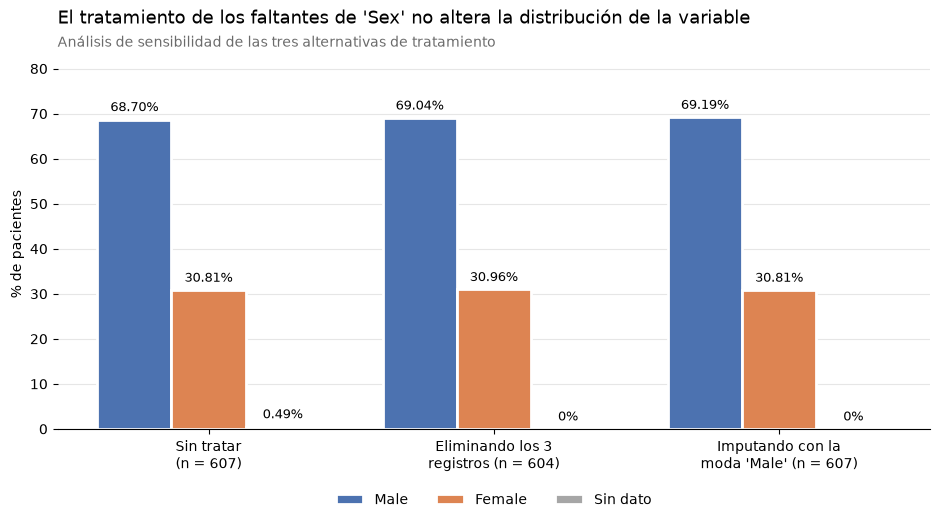

In [80]:


n_male = (clinical_df['Sex'] == 'Male').sum()
n_female = (clinical_df['Sex'] == 'Female').sum()
n_falt = clinical_df['Sex'].isnull().sum()
n_conocidos = n_male + n_female

escenarios = [
    f"Sin tratar\n(n = {n_total})",
    f"Eliminando los {n_falt}\nregistros (n = {n_conocidos})",
    f"Imputando con la\nmoda 'Male' (n = {n_total})",
]
male     = [n_male/n_total*100, n_male/n_conocidos*100, (n_male + n_falt)/n_total*100]
female   = [n_female/n_total*100, n_female/n_conocidos*100, n_female/n_total*100]
sin_dato = [n_falt/n_total*100, 0.0, 0.0]

x = np.arange(len(escenarios))
w = 0.26

fig, ax = plt.subplots(figsize=(9.5, 5.4))
b1 = ax.bar(x - w, male, w, label='Male', color='#4C72B0', edgecolor='white', linewidth=2)
b2 = ax.bar(x, female, w, label='Female', color='#DD8452', edgecolor='white', linewidth=2)
b3 = ax.bar(x + w, sin_dato, w, label='Sin dato', color='#A6A6A6', edgecolor='white', linewidth=2)

for barras in (b1, b2, b3):
    for barra in barras:
        alto = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, alto + 1.2,
                f'{alto:.2f}%' if alto > 0 else '0%',
                ha='center', va='bottom', fontsize=9)

ax.set_title("El tratamiento de los faltantes de 'Sex' no altera la distribución de la variable",
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035, 'Análisis de sensibilidad de las tres alternativas de tratamiento',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% de pacientes')
ax.set_xticks(x)
ax.set_xticklabels(escenarios)
ax.set_ylim(0, 82)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3)

plt.tight_layout()
plt.show()

**Criterio de decisión y tratamiento aplicado**

Para decidir entre eliminar los registros o imputarlos, se realizó un análisis de sensibilidad comparando la distribución resultante de `Sex` bajo los tres escenarios posibles.

El resultado muestra que la proporción de hombres se mantiene entre 68.70% y 69.19%, y la de mujeres entre 30.81% y 30.96%, independientemente del tratamiento aplicado. La diferencia máxima entre eliminar los registros e imputarlos con la moda es de 0.15 puntos porcentuales, una variación sin ninguna relevancia práctica para el análisis.

Dado que ambas alternativas producen esencialmente el mismo resultado sobre la variable, el criterio de decisión pasa a ser cuál de las dos preserva mayor cantidad de información. Por esta razón se optó por **imputar los 3 valores con la moda (`Male`)** en lugar de eliminar los registros, con base en tres consideraciones:

1. Los 3 pacientes afectados cuentan con datos completos en variables clínicamente más determinantes para el desenlace, como `Shockable Rhythm`, `ROSC` y `Outcome`. Eliminarlos implicaría descartar esa información a cambio de un beneficio nulo.
2. El conjunto de datos es relativamente pequeño (607 pacientes) y la clase minoritaria de la variable objetivo cuenta con solo 225 casos `Good`, por lo que la pérdida de registros debe evitarse siempre que sea posible.
3. En la Fase 2 se estableció que `Sex` presenta una asociación muy débil con el desenlace neurológico. Esto se evidenció en el gráfico de **barras de proporción de `Outcome` según `Sex`**, donde la diferencia en la proporción de casos `Good` entre hombres y mujeres fue de apenas 6 puntos porcentuales (38.6% frente a 32.8%), y se confirmó numéricamente en la **matriz de correlación extendida**, donde `Sex_num` presentó una correlación cercana a cero con `Outcome_num`, muy por debajo de la de otras variables como `Shockable Rhythm` (-0.37). Dado que el sexo no es un factor determinante del desenlace en este conjunto de datos, una eventual imputación incorrecta en 3 pacientes no introduce sesgo apreciable en los análisis de asociación posteriores.

**Variable `OHCA`**



`OHCA` (Out-of-Hospital Cardiac Arrest) es una variable categórica binaria que indica si el paro cardíaco ocurrió fuera del hospital (`True`) o dentro de este (`False`). Es la variable categórica con mayor proporción de valores faltantes del conjunto de datos.

A diferencia de `Sex`, donde el faltante era marginal, aquí el grupo sin dato es lo suficientemente grande como para evaluar si su ausencia responde a un patrón sistemático. Por ello el criterio de decisión no será un análisis de sensibilidad, sino determinar si el faltante constituye en sí mismo información relevante frente a la variable objetivo.

Para determinar si la ausencia del dato constituye información relevante, se comparó la proporción de pacientes con desenlace `Good` en cada categoría de `OHCA`, incluyendo el grupo sin dato.

| Categoría | % con desenlace Good | n |
|---|---|---|
| Fuera del hospital (`True`) | 38.2% | 442 |
| Dentro del hospital (`False`) | 33.1% | 124 |
| Sin dato | 36.6% | 41 |
| **Cohorte completa** | **37.1%** | **607** |

El grupo sin dato presenta un 36.6% de desenlaces favorables, prácticamente idéntico al 37.1% de la cohorte completa y ubicado entre las dos categorías conocidas. Esto indica que los pacientes sin registro de `OHCA` no constituyen un subgrupo con un pronóstico diferenciado, sino que se comportan como el promedio del conjunto de datos. El hallazgo es coherente con el análisis por hospital, que atribuye la ausencia del dato a diferencias en las prácticas de documentación institucional y no a características clínicas de los pacientes.



In [81]:
clinical_df['OHCA'] = clinical_df['OHCA'].replace('nan', pd.NA)

n_falt = clinical_df['OHCA'].isnull().sum()
print(f"Valores faltantes en OHCA: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['OHCA'].value_counts(dropna=False).to_string())

print("\nDistribución por hospital de los pacientes SIN dato de OHCA:")
falt_hosp = clinical_df.loc[clinical_df['OHCA'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Valores faltantes en OHCA: 41 (6.8%)

Distribución de las categorías:
OHCA
True     442
False    124
NaN       41

Distribución por hospital de los pacientes SIN dato de OHCA:
          Faltantes  Total pacientes  % del hospital
Hospital                                            
A                26              261            10.0
B                 0              120             0.0
D                11               83            13.3
E                 3               74             4.1
F                 1               69             1.4


**Análisis de la distribución de los faltantes**

Al examinar el origen institucional de los 41 registros sin dato, se observa que los faltantes no se distribuyen de manera uniforme entre los hospitales del consorcio:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 26 | 261 | 10.0% |
| B | 0 | 120 | 0.0% |
| D | 11 | 83 | 13.3% |
| E | 3 | 74 | 4.1% |
| F | 1 | 69 | 1.4% |

La proporción de faltantes varía entre 0.0% y 13.3% según la institución, y los hospitales A y D concentran 37 de los 41 casos (90%). El contraste más notorio es el del Hospital B, que no presenta ningún valor faltante en 120 pacientes, frente al Hospital D, con 13.3% de sus registros incompletos.

Este patrón indica que la ausencia del dato no responde a una característica clínica de los pacientes, sino a diferencias en las prácticas de registro y documentación entre instituciones. Es decir, se trata de un faltante asociado a la variable `Hospital` y no aleatorio en sentido estricto.

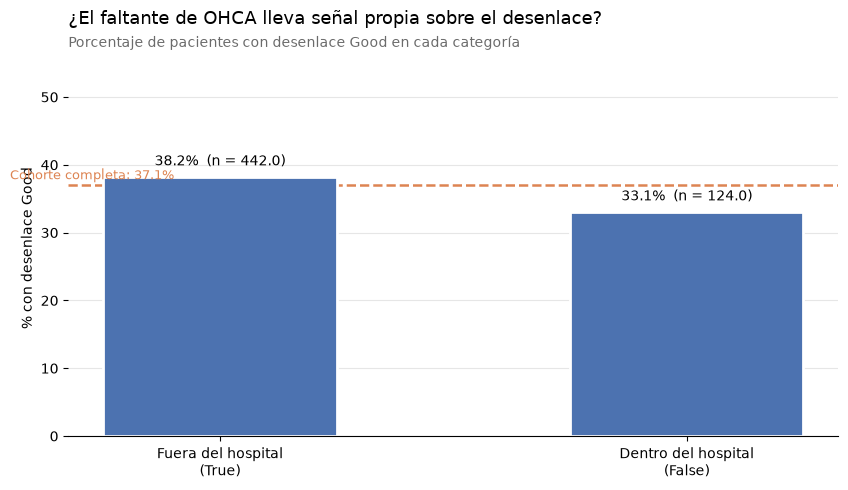

In [83]:
grupos = clinical_df['OHCA'].astype(str).replace({'<NA>': 'Sin dato', 'nan': 'Sin dato'})
tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Fuera del hospital\n(True)', 'Dentro del hospital\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.2,
            f'{pct:.1f}%  (n = {n})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)
ax.text(-0.45, baseline + 0.8, f'Cohorte completa: {baseline:.1f}%',
        ha='left', fontsize=9, color='#DD8452')

ax.set_title('¿El faltante de OHCA lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035, 'Porcentaje de pacientes con desenlace Good en cada categoría',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.45)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

**Evaluación de si el faltante lleva señal propia**

Para determinar si la ausencia del dato constituye información relevante, se comparó la proporción de pacientes con desenlace `Good` en cada categoría de `OHCA`, incluyendo el grupo sin dato.

| Categoría | % con desenlace Good | n |
|---|---|---|
| Fuera del hospital (`True`) | 38.2% | 442 |
| Dentro del hospital (`False`) | 33.1% | 124 |
| Sin dato | 36.6% | 41 |
| **Cohorte completa** | **37.1%** | **607** |

El grupo sin dato presenta un 36.6% de desenlaces favorables, prácticamente idéntico al 37.1% de la cohorte completa y ubicado entre las dos categorías conocidas. Esto indica que los pacientes sin registro de `OHCA` no constituyen un subgrupo con un pronóstico diferenciado, sino que se comportan como el promedio del conjunto de datos. El hallazgo sugiere que la ausencia del dato se debe a diferencias en las prácticas de documentación institucional y no a características clínicas de los pacientes.

**Criterio de decisión y tratamiento aplicado**

Con ambas evidencias se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros.

La decisión se fundamenta en una asimetría de costos entre las alternativas. Conservar la categoría no tiene costo analítico, dado que el grupo sin dato se comporta como el promedio de la cohorte y por lo tanto no distorsiona las comparaciones de desenlace entre categorías. Imputar con la moda, en cambio, sí tiene un costo concreto: desplazaría la distribución de la variable de 72.8% a 79.6% de casos `True`, y atribuiría a 41 pacientes una característica clínica desconocida, cuando la única causa documentada de la ausencia es la práctica de registro de sus hospitales de origen. Eliminar los registros tampoco es viable, porque los faltantes se concentran en los hospitales A y D, lo que sub-representaría sistemáticamente a esas instituciones en todos los análisis posteriores.

Se evaluó adicionalmente una imputación por moda dentro de cada hospital, más refinada que la moda global, pero se descartó porque el 90% de los faltantes proviene de A y D, donde la moda también es `True`, con lo cual el resultado sería equivalente al de la imputación global sin resolver el problema de fondo.

Finalmente, conservar una tercera categoría no representa ninguna limitación para las fases posteriores, ya que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [ ]:
clinical_df['OHCA'] = clinical_df['OHCA'].astype(object).fillna('Desconocido')

print("Distribución final de OHCA:")
dist = clinical_df['OHCA'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes en OHCA: {clinical_df['OHCA'].isnull().sum()}")
assert clinical_df['OHCA'].isnull().sum() == 0, "Aún quedan faltantes en OHCA"
print("Verificación superada: la variable OHCA no contiene valores faltantes.")

Distribución final de OHCA:
  True: 442 (72.8%)
  False: 124 (20.4%)
  Desconocido: 41 (6.8%)

Valores faltantes restantes en OHCA: 0
Verificación superada: la variable OHCA no contiene valores faltantes.


**Variable `Shockable Rhythm`**

`Shockable Rhythm` es una variable categórica binaria que indica si el ritmo cardíaco inicial del paciente era desfibrilable (`True`), por ejemplo fibrilación ventricular, o no desfibrilable (`False`). Presenta 32 valores faltantes, equivalentes al 5.3% del conjunto.

Esta variable requiere el criterio de tratamiento más cuidadoso, por dos razones establecidas en la Fase 2. Primero, es la variable con la asociación más fuerte con el desenlace neurológico de todo el conjunto de datos: presentó la correlación de mayor magnitud con `Outcome` (-0.37) y una diferencia de 38 puntos porcentuales en la proporción de casos `Good` entre sus dos categorías (55% con ritmo desfibrilable frente a 17% sin él). Segundo, sus dos categorías están prácticamente equilibradas (297 casos `True` frente a 278 `False`), a diferencia de `OHCA`, donde existía una mayoría clara.

Cualquier valor asignado de forma incorrecta en esta variable tiene, por lo tanto, un impacto mucho mayor sobre los análisis posteriores que en las variables anteriores.

In [ ]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].replace('nan', pd.NA)

n_falt = clinical_df['Shockable Rhythm'].isnull().sum()
print(f"Valores faltantes en Shockable Rhythm: {n_falt} ({n_falt/n_total*100:.1f}%)\n")
print("Distribución de las categorías:")
print(clinical_df['Shockable Rhythm'].value_counts(dropna=False).to_string())

conocidos = clinical_df['Shockable Rhythm'].dropna()
print("\nDistribución entre los casos conocidos (%):")
print((conocidos.value_counts(normalize=True) * 100).round(1).to_string())

print("\nDistribución por hospital de los pacientes SIN dato:")
falt_hosp = clinical_df.loc[clinical_df['Shockable Rhythm'].isnull(), 'Hospital'].value_counts()
total_hosp = clinical_df['Hospital'].value_counts()
comparacion = pd.DataFrame({
    'Faltantes': falt_hosp,
    'Total pacientes': total_hosp,
}).fillna(0).astype(int)
comparacion['% del hospital'] = (comparacion['Faltantes'] / comparacion['Total pacientes'] * 100).round(1)
print(comparacion.to_string())

Valores faltantes en Shockable Rhythm: 32 (5.3%)

Distribución de las categorías:
Shockable Rhythm
True     297
False    278
<NA>      32

Distribución entre los casos conocidos (%):
Shockable Rhythm
True     51.7
False    48.3

Distribución por hospital de los pacientes SIN dato:
          Faltantes  Total pacientes  % del hospital
Hospital                                            
A                32              261            12.3
B                 0              120             0.0
D                 0               83             0.0
E                 0               74             0.0
F                 0               69             0.0


**Análisis de la distribución de los faltantes**

El examen del origen institucional de los 32 registros sin dato arroja un resultado inequívoco:

| Hospital | Faltantes | Total pacientes | % del hospital |
|---|---|---|---|
| A | 32 | 261 | 12.3% |
| B | 0 | 120 | 0.0% |
| D | 0 | 83 | 0.0% |
| E | 0 | 74 | 0.0% |
| F | 0 | 69 | 0.0% |

La totalidad de los valores faltantes proviene del Hospital A, mientras que los cuatro hospitales restantes no presentan ni un solo registro incompleto en 346 pacientes. Se trata por lo tanto de una carencia de documentación exclusiva de una institución, sin relación con las características clínicas de los pacientes.

Este hallazgo es más categórico que el observado en `OHCA`, donde los faltantes se repartían en distinta proporción entre cuatro hospitales. Aquí la ausencia del dato depende por completo del centro de origen, lo que descarta interpretarla como una señal clínica.

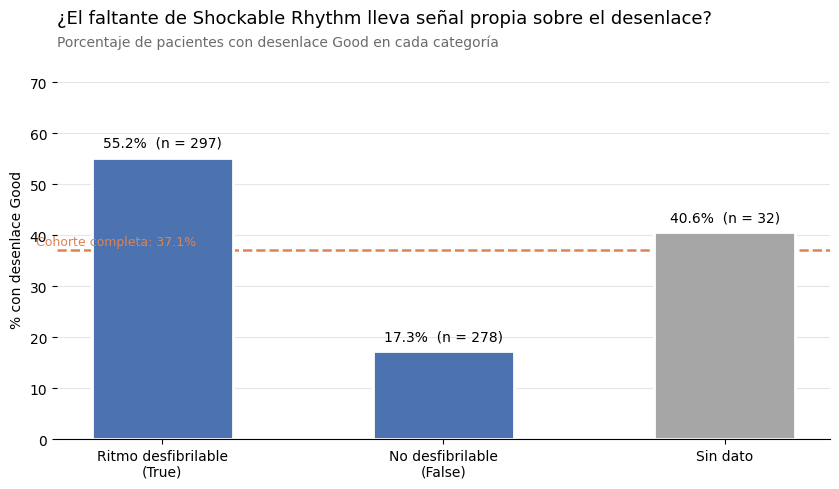

Shockable Rhythm
True        55.2
False       17.3
Sin dato    40.6


In [ ]:
grupos = clinical_df['Shockable Rhythm'].astype(str).replace({'<NA>': 'Sin dato', 'nan': 'Sin dato'})
tabla = pd.crosstab(grupos, clinical_df['Outcome'])
pct_good = (tabla['Good'] / tabla.sum(axis=1) * 100)
conteos = tabla.sum(axis=1)

orden = ['True', 'False', 'Sin dato']
pct_good = pct_good.reindex(orden)
conteos = conteos.reindex(orden)

baseline = (clinical_df['Outcome'] == 'Good').mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.bar(['Ritmo desfibrilable\n(True)', 'No desfibrilable\n(False)', 'Sin dato'],
                pct_good.values, width=0.5,
                color=['#4C72B0', '#4C72B0', '#A6A6A6'], edgecolor='white', linewidth=2)

for barra, pct, n in zip(barras, pct_good.values, conteos.values):
    ax.text(barra.get_x() + barra.get_width()/2, pct + 1.5,
            f'{pct:.1f}%  (n = {n})', ha='center', va='bottom', fontsize=10)

ax.axhline(baseline, color='#DD8452', linestyle='--', linewidth=1.8, zorder=0)
ax.text(-0.45, baseline + 1.0, f'Cohorte completa: {baseline:.1f}%',
        ha='left', fontsize=9, color='#DD8452')

ax.set_title('¿El faltante de Shockable Rhythm lleva señal propia sobre el desenlace?',
             fontsize=13, pad=26, loc='left')
ax.text(0, 1.035, 'Porcentaje de pacientes con desenlace Good en cada categoría',
        transform=ax.transAxes, fontsize=10, color='#6b6b6b')
ax.set_ylabel('% con desenlace Good')
ax.set_ylim(0, max(pct_good.max(), baseline) * 1.35)
ax.yaxis.grid(True, color='#e6e6e6', linewidth=0.8)
ax.set_axisbelow(True)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.show()

print(pct_good.round(1).to_string())

In [ ]:
conocidos = clinical_df['Shockable Rhythm'].dropna()
conocidos = conocidos[conocidos != 'Desconocido']

moda = conocidos.mode()[0]
pct_moda = (conocidos == moda).mean() * 100
error_esperado = round(n_falt * (1 - pct_moda / 100))

print(f"Moda de la variable: '{moda}', presente en {pct_moda:.1f}% de los casos conocidos")
print(f"Al imputar los {n_falt} faltantes con la moda se esperaría clasificar")
print(f"incorrectamente alrededor de {error_esperado} pacientes ({100 - pct_moda:.1f}% de ellos).\n")

# Composición implícita del grupo sin dato, estimada a partir de su tasa de desenlace favorable
p_true, p_false, p_sindato = pct_good['True'], pct_good['False'], pct_good['Sin dato']
prop_true_estimada = (p_sindato - p_false) / (p_true - p_false)
print(f"Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:")
print(f"  aproximadamente {prop_true_estimada*100:.0f}% True  ({round(n_falt*prop_true_estimada)} pacientes)")
print(f"  aproximadamente {(1-prop_true_estimada)*100:.0f}% False ({round(n_falt*(1-prop_true_estimada))} pacientes)")

Moda de la variable: 'True', presente en 51.7% de los casos conocidos
Al imputar los 32 faltantes con la moda se esperaría clasificar
incorrectamente alrededor de 15 pacientes (48.3% de ellos).

Composición estimada del grupo sin dato a partir de su tasa de desenlace favorable:
  aproximadamente 62% True  (20 pacientes)
  aproximadamente 38% False (12 pacientes)


**Evaluación de si el faltante lleva señal propia**

| Categoría | % con desenlace Good | n |
|---|---|---|
| Ritmo desfibrilable (`True`) | 55.2% | 297 |
| No desfibrilable (`False`) | 17.3% | 278 |
| Sin dato | 40.6% | 32 |
| **Cohorte completa** | **37.1%** | **607** |

La diferencia entre las dos categorías conocidas es de 37.9 puntos porcentuales, la mayor observada entre todas las variables del conjunto, lo que confirma a `Shockable Rhythm` como el factor pronóstico más determinante disponible.

El grupo sin dato presenta un 40.6% de desenlaces favorables, un valor que no se aproxima a ninguna de las dos categorías conocidas y que se ubica cerca del promedio general de la cohorte. Este comportamiento intermedio es característico de un grupo mixto y no de uno que pertenezca mayoritariamente a una sola categoría. Asumiendo que su tasa de desenlace favorable corresponde a una combinación ponderada de ambas categorías, la proporción implícita de casos `True` en ese grupo sería cercana al 61%, es decir, alrededor de 20 pacientes `True` y 12 `False`.

**Criterio de decisión y tratamiento aplicado**

Se optó por **conservar los valores faltantes como una categoría explícita `"Desconocido"`**, en lugar de imputarlos o eliminar los registros. Esta es la variable donde dicha decisión cuenta con el fundamento más sólido de las tres, por cuatro razones.

Primero, la moda no constituye una mayoría significativa. Entre los casos conocidos la distribución es de 51.7% `True` frente a 48.3% `False`, prácticamente equilibrada. La imputación por moda es un procedimiento defendible cuando existe una categoría claramente dominante, pero con una mayoría del 51.7% equivale a asignar valores casi de forma aleatoria.

Segundo, el costo del error es el más alto del conjunto de datos. Al estimarse que cerca de 12 de los 32 pacientes pertenecen realmente a la categoría `False`, imputarlos todos como `True` los desplazaría desde un grupo con 17.3% de desenlaces favorables hacia uno con 55.2%, introduciendo ruido precisamente en la variable con mayor capacidad discriminante sobre el desenlace neurológico.

Tercero, el perfil intermedio del grupo sin dato indica que se trata de una mezcla de ambas categorías, por lo que ningún valor único sería representativo del conjunto de pacientes afectados.

Cuarto, la totalidad de los faltantes proviene del Hospital A. Eliminar esos registros sub-representaría a la institución que aporta el 43% de la cohorte, mientras que imputarlos ocultaría un hallazgo relevante sobre la calidad del registro en ese centro. Conservar la categoría explícita mantiene visible esa limitación de los datos en lugar de disimularla.

Al igual que en `OHCA`, la tercera categoría no representa ninguna limitación técnica para las fases posteriores, dado que la codificación one-hot la maneja de forma nativa en cualquier modelo de clasificación.

In [ ]:
clinical_df['Shockable Rhythm'] = clinical_df['Shockable Rhythm'].astype(object).fillna('Desconocido')

print("Distribución final de Shockable Rhythm:")
dist = clinical_df['Shockable Rhythm'].value_counts()
for cat, n in dist.items():
    print(f"  {cat}: {n} ({n/len(clinical_df)*100:.1f}%)")

print(f"\nValores faltantes restantes: {clinical_df['Shockable Rhythm'].isnull().sum()}")
assert clinical_df['Shockable Rhythm'].isnull().sum() == 0, "Aún quedan faltantes"
print("Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.")

Distribución final de Shockable Rhythm:
  True: 297 (48.9%)
  False: 278 (45.8%)
  Desconocido: 32 (5.3%)

Valores faltantes restantes: 0
Verificación superada: la variable Shockable Rhythm no contiene valores faltantes.



Al comparar el origen de los faltantes de las tres variables categóricas se identifica un patrón que trasciende cada caso individual. Los 32 faltantes de `Shockable Rhythm` provienen en su totalidad del Hospital A, y 26 de los 41 faltantes de `OHCA` provienen de esa misma institución. En conjunto, el Hospital A concentra 58 de los 76 valores faltantes del conjunto de variables categóricas, es decir el 76% del total.

Esto indica que no se trata de incidencias aisladas e independientes en cada variable, sino de una deficiencia sistemática en las prácticas de documentación de las circunstancias del paro cardíaco en ese centro. Dado que el Hospital A aporta el 43% de la cohorte, esta limitación debe tenerse presente al interpretar cualquier análisis que involucre estas dos variables, y constituye en sí misma un hallazgo relevante sobre la calidad del conjunto de datos.

### **1.2. Valores duplicados**
----
Ante la presencia de valores duplicados, es esencial reflexionar sobre su impacto en los resultados.

* ¿Cómo se identificaron y manejaron los valores duplicados en el conjunto de datos?
* ¿Hubo alguna consideración especial al tratar duplicados en función de ciertas variables?
* ¿Pueden estos duplicados sesgar el análisis, y en qué medida?
* ¿Se justifica la eliminación de duplicados para mantener la coherencia y singularidad de los datos?
* ¿Cómo se aseguró de que la eliminación de duplicados no afectara negativamente la representación del conjunto de datos?

La identificación y eliminación de duplicados busca asegurar que cada registro aporte información única y valiosa.

---**INGRESE SU RESPUESTA**---

In [ ]:
# ---INGRESE SU CÓDIGO---

### **1.3. Valores atípicos**
---
Al abordar valores atípicos, es relevante cuestionarse sobre la naturaleza de estos puntos extremos.
* ¿Son errores de medición o representan información válida pero excepcional?
* ¿Qué criterios o técnicas se utilizaron para identificar los valores atípicos?
* ¿Se aplicaron métodos estadísticos o visuales para detectar los valores atípicos?
* ¿Cuál fue la decisión final sobre cómo tratar los valores atípicos y por qué?

La elección entre eliminar o transformar estos valores debe basarse en su influencia en la distribución y la interpretación de los resultados, asegurando que el análisis refleje de manera precisa la realidad del conjunto de datos.

---**INGRESE SU RESPUESTA**---

In [ ]:
# ---INGRESE SU CÓDIGO---

### **1.4. Datos Inconsistentes**
---
Frente a inconsistencias en los datos, es importante analizar cómo estas discrepancias podrían afectar la comparabilidad y comprensión de la información.

* ¿Cómo se identificaron las inconsistencias en los datos?
* ¿Las inconsistencias son lo suficientemente significativas como para justificar una estandarización?
* ¿Cómo se pueden homogeneizar unidades y formatos para garantizar coherencia en el análisis?
* ¿Qué estrategias se implementaron para abordar las inconsistencias y asegurar la coherencia?
* ¿Se establecieron reglas de validación específicas para garantizar la consistencia?

---**INGRESE SU RESPUESTA**---

In [ ]:
# ---INGRESE SU CÓDIGO---

### **1.5. Datos corruptos**
---
En la detección de datos corruptos, pregunte si hay posibles errores de entrada o problemas de transferencia que podrían haber afectado la integridad de los datos.
* ¿Cómo se determinó la presencia de datos corruptos en el conjunto de datos?
* ¿Qué medidas se tomaron para corregir o eliminar los datos corruptos?
* ¿Hubo casos en los que la corrupción de datos no pudo ser manejada y cómo se justificó esa decisión?

---**INGRESE SU RESPUESTA**---

In [ ]:
# ---INGRESE SU CÓDIGO---

### **1.6. Selección de datos**
---
En la selección de datos, reflexione sobre las variables que son realmente relevantes para sus objetivos de análisis.
* ¿Qué criterios se utilizaron para seleccionar los datos relevantes para el análisis?
* ¿Se aplicaron técnicas de muestreo o filtrado para reducir el tamaño del conjunto de datos?
* ¿Cómo se justificó la inclusión o exclusión de ciertas variables en la selección de datos?

---**INGRESE SU RESPUESTA**---

### Preprocesamiento y transformación

In [ ]:
# ---INGRESE SU CÓDIGO---

# Records

### Faltantes

### Duplicados

### Atipicos

### Inconsistentes

### Corruptos

### Selección de los datos

### Preprocesamiento y transformación

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*